<a href="https://colab.research.google.com/github/DHRUVCHARNE/AI-Learn-Notebooks/blob/main/makemore_using_wavenet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [61]:
# read in all the words
words = open('/content/names.txt','r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:5])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia']


In [62]:
# build the vocabulary
chars = sorted(list(set("".join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
itos={i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [63]:
# build the dataset
block_size = 16  # How many characters do we take to predict the next one?
def build_dataset(words):
  X,Y = [],[]
  for w in words:
    context = [0]*block_size
    for ch in w+'.':
      ix=stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:]+[ix]
  X = torch.tensor(X)
  Y= torch.tensor(Y)
  print(X.shape,Y.shape)
  return X,Y
import random
random.seed(41)
random.shuffle(words)
n1 = int(0.8*len(words))
n2= int(0.9*len(words))
Xtr,Ytr = build_dataset(words[:n1])
Xdev,Ydev = build_dataset(words[n1:n2])
Xte,Yte = build_dataset(words[n2:])


torch.Size([182397, 16]) torch.Size([182397])
torch.Size([22905, 16]) torch.Size([22905])
torch.Size([22844, 16]) torch.Size([22844])


In [64]:
for x,y in zip(Xtr[:20], Ytr[:20]):
  print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

................ --> n
...............n --> i
..............ni --> s
.............nis --> h
............nish --> a
...........nisha --> n
..........nishan --> t
.........nishant --> .
................ --> n
...............n --> i
..............ni --> t
.............nit --> a
............nita --> .
................ --> m
...............m --> a
..............ma --> n
.............man --> v
............manv --> i
...........manvi --> t
..........manvit --> h


In [65]:
# Near copy paste of the layers we have developed in Part 3

# -----------------------------------------------------------------------------------------------
class Linear:

  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5 # note: kaiming init
    self.bias = torch.zeros(fan_out) if bias else None

  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])

# -----------------------------------------------------------------------------------------------
class BatchNorm1d:

  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)

  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      if x.ndim == 2:
        dim = 0
      elif x.ndim == 3:
        dim = (0,1)
      xmean = x.mean(dim, keepdim=True) # batch mean
      xvar = x.var(dim, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out

  def parameters(self):
    return [self.gamma, self.beta]

# -----------------------------------------------------------------------------------------------
class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

# -----------------------------------------------------------------------------------------------
class Embedding:

  def __init__(self, num_embeddings, embedding_dim):
    self.weight = torch.randn((num_embeddings, embedding_dim))

  def __call__(self, IX):
    self.out = self.weight[IX]
    return self.out

  def parameters(self):
    return [self.weight]

# -----------------------------------------------------------------------------------------------
class FlattenConsecutive:

  def __init__(self, n):
    self.n = n

  def __call__(self, x):
    B, T, C = x.shape
    x = x.view(B, T//self.n, C*self.n)
    if x.shape[1] == 1:
      x = x.squeeze(1)
    self.out = x
    return self.out

  def parameters(self):
    return []

# -----------------------------------------------------------------------------------------------
class Sequential:

  def __init__(self, layers):
    self.layers = layers

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return self.out

  def parameters(self):
    # get parameters of all layers and stretch them out into one list
    return [p for layer in self.layers for p in layer.parameters()]

In [66]:
torch.manual_seed(42)

In [67]:
n_embd=24
n_hidden=512
model = Sequential([
    Embedding(vocab_size,n_embd),
    FlattenConsecutive(2),
    Linear(n_embd*2,n_hidden,bias=False),BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2),Linear(n_hidden*2,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    FlattenConsecutive(2),Linear(n_hidden*2,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    FlattenConsecutive(2),Linear(n_hidden*2,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,vocab_size)])
# parameter init
with torch.no_grad():
  model.layers[-1].weight *=0.1 # Make last layer less confident
parameters = model.parameters()
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad=True

1616035


In [68]:
import math
lr_max=0.1
lr_min=0.000000001

In [69]:
# same optimization as last time
max_steps = 20000
batch_size = 32
lossi = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

  # forward pass
  logits = model(Xb)
  loss = F.cross_entropy(logits, Yb) # loss function

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update: simple SGD
  lr = lr_min + 0.5*(lr_max-lr_min)*(1 + math.cos(math.pi*i/max_steps)) # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 1000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/  20000: 3.3144
   1000/  20000: 2.6159
   2000/  20000: 2.1864
   3000/  20000: 2.0420
   4000/  20000: 1.9137
   5000/  20000: 2.2123
   6000/  20000: 1.9166
   7000/  20000: 2.2667
   8000/  20000: 2.0269
   9000/  20000: 2.4470
  10000/  20000: 2.4754
  11000/  20000: 1.9304
  12000/  20000: 1.8844
  13000/  20000: 2.0872
  14000/  20000: 1.7121
  15000/  20000: 1.8706
  16000/  20000: 1.6660
  17000/  20000: 1.9924
  18000/  20000: 1.5187
  19000/  20000: 1.9656


In [70]:
loss.item()

1.9082039594650269

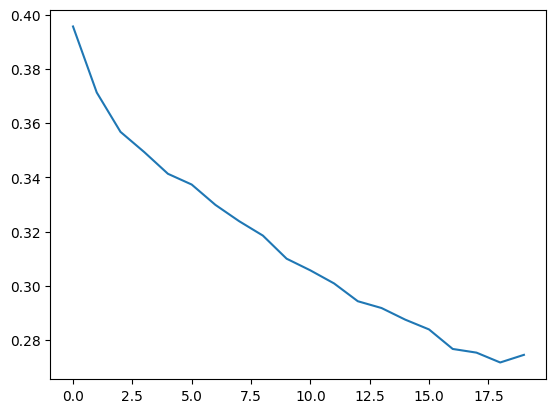

In [71]:
plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))

In [72]:
for layer in model.layers:
  layer.training = False

In [73]:
# evaluate the loss
@torch.no_grad() # this decorator disables gradient tracking inside pytorch
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  logits = model(x)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('test')
split_loss('val')

test 1.986678123474121
val 1.9927468299865723


In [74]:
# sample from the model
for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      logits = model(torch.tensor([context]))
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break

    print(''.join(itos[i] for i in out)) # decode and print the generated word

makol.
ryien.
ammy.
jomanie.
dorahna.
odtecra.
zybita.
halihar.
vanan.
jereni.
loxmer.
cabi.
melle.
larcyse.
cail.
behlo.
shambell.
k.
jalami.
keloa.
